<a href="https://colab.research.google.com/github/hassan310120/MSc-Final-Project/blob/main/Kepler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **A Comparative Study of Time Series and Machine Learning Models for Kepler Light Curve Analysis**

In [ ]:
#Mount the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip -q install astropy

from astropy.io import fits
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from astropy.timeseries import LombScargle
from astropy.stats import sigma_clip

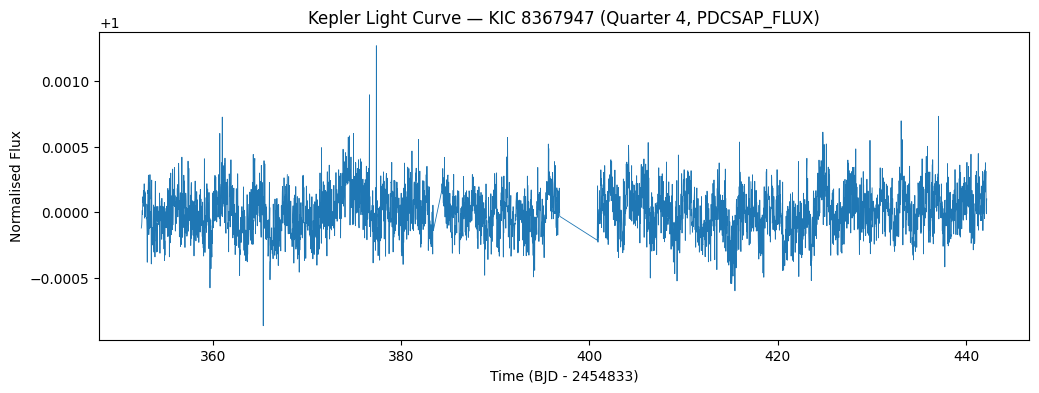

In [ ]:
file_path = "/content/drive/MyDrive/kplr008367947-2010078095331_llc.fits"

with fits.open(file_path) as hdul:
    data = hdul[1].data
    time = data["TIME"]
    flux = data["PDCSAP_FLUX"]   # cleaned flux (best default)

# remove NaNs
mask = np.isfinite(time) & np.isfinite(flux)
time = time[mask]
flux = flux[mask]

# normalise
flux_norm = flux / np.median(flux)

plt.figure(figsize=(12,4))
plt.plot(time, flux_norm, linewidth=0.6)
plt.xlabel("Time (BJD - 2454833)")
plt.ylabel("Normalised Flux")
plt.title("Kepler Light Curve — KIC 8367947 (Quarter 4, PDCSAP_FLUX)")
plt.show()


In [ ]:
print("Points:", len(time))
print("Time range:", float(time.min()), "to", float(time.max()))
print("Median flux:", float(np.median(flux)))
print("Std (normalised):", float(np.std(flux_norm)))


Points: 4108
Time range: 352.3972485105478 to 442.2027946413873
Median flux: 68017.6484375
Std (normalised): 0.00017586248577572405


### Time Series Model 1: Moving Average (Baseline)

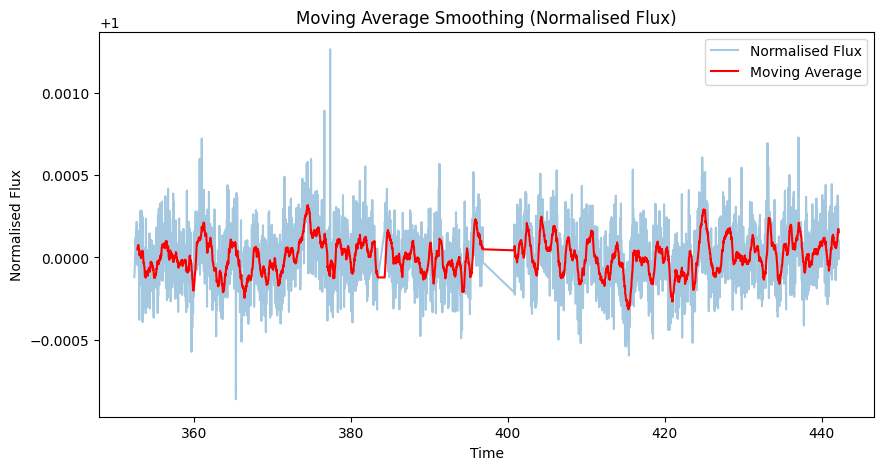

In [ ]:
window_size = 20  # adjust later
smoothed_flux = pd.Series(flux_norm).rolling(window=window_size).mean()

plt.figure(figsize=(10,5))
plt.plot(time, flux_norm, alpha=0.4, label="Normalised Flux")
plt.plot(time, smoothed_flux, color="red", label="Moving Average")
plt.legend()
plt.title("Moving Average Smoothing (Normalised Flux)")
plt.xlabel("Time")
plt.ylabel("Normalised Flux")
plt.show()

In [ ]:
valid_idx = ~np.isnan(smoothed_flux)
ma_deviation = np.sqrt(mean_squared_error(flux_norm[valid_idx], smoothed_flux[valid_idx]))
print("Moving Average Deviation:", ma_deviation)

Moving Average Deviation: 0.0001507311858181747


### Time Series Model 2: ARIMA

ADF Statistic: -17.489232924187366
p-value: 4.446149942053402e-30
ARIMA RMSE: 0.00017215166064934957


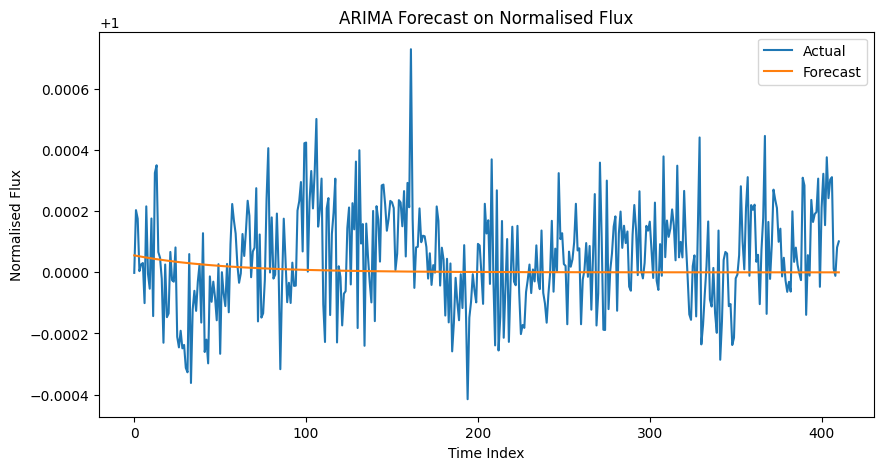

In [ ]:
#Check Stationarity
result = adfuller(np.diff(flux_norm))
print("ADF Statistic:", result[0])
print("p-value:", result[1])

#Train/Test Split
split = int(len(flux_norm) * 0.9)
train, test = flux_norm[:split], flux_norm[split:]

#Evaluate
model = ARIMA(train, order=(1,0,1),
              enforce_stationarity=False,
              enforce_invertibility=False)

model_fit = model.fit()
forecast = model_fit.forecast(steps=len(test))

rmse_arima = np.sqrt(mean_squared_error(test, forecast))
print("ARIMA RMSE:", rmse_arima)

#Plot
plt.figure(figsize=(10,5))
plt.plot(test, label="Actual")
plt.plot(forecast, label="Forecast")
plt.legend()
plt.title("ARIMA Forecast on Normalised Flux")
plt.xlabel("Time Index")
plt.ylabel("Normalised Flux")
plt.show()

Model 3: Lomb-Scargle Periodogram

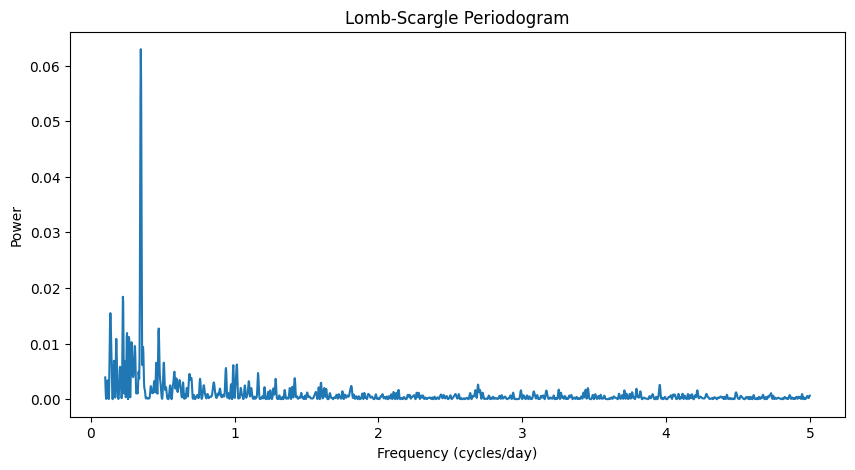

Best Frequency: 0.3472007682872545
Estimated Period (days): 2.8801779585137783
Estimated Period (hours): 69.12427100433068


In [ ]:
# Define frequency range properly
min_freq = 0.1      # avoid ultra-long trends
max_freq = 5       # below Nyquist limit (~24)

frequency, power = LombScargle(time, flux).autopower(
    minimum_frequency=min_freq,
    maximum_frequency=max_freq
)

plt.figure(figsize=(10,5))
plt.plot(frequency, power)
plt.title("Lomb-Scargle Periodogram")
plt.xlabel("Frequency (cycles/day)")
plt.ylabel("Power")
plt.show()

best_frequency = frequency[np.argmax(power)]
period = 1 / best_frequency

print("Best Frequency:", best_frequency)
print("Estimated Period (days):", period)
print("Estimated Period (hours):", period * 24)

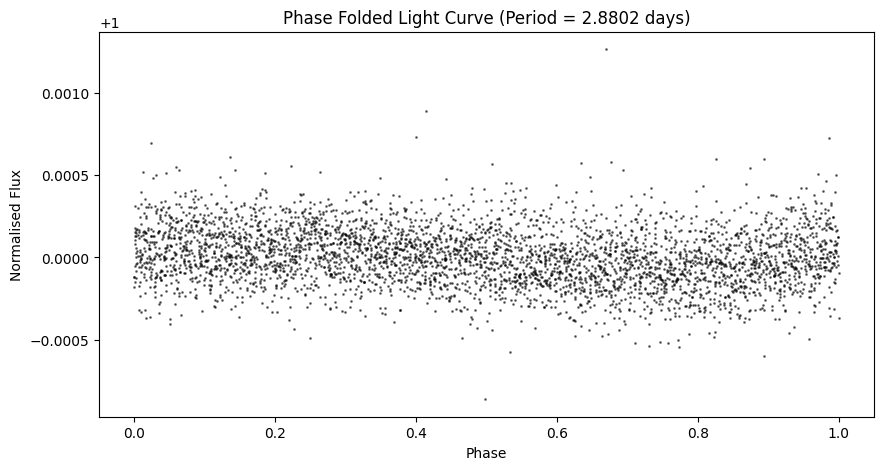

In [ ]:
# 1. Calculate phases
t0 = time[0]
phases = ((time - t0) / period) % 1

# 2. Plot the folded light curve
plt.figure(figsize=(10, 5))
plt.scatter(phases, flux_norm, s=1, color='black', alpha=0.5)
plt.xlabel("Phase")
plt.ylabel("Normalised Flux")
plt.title(f"Phase Folded Light Curve (Period = {period:.4f} days)")
plt.show()

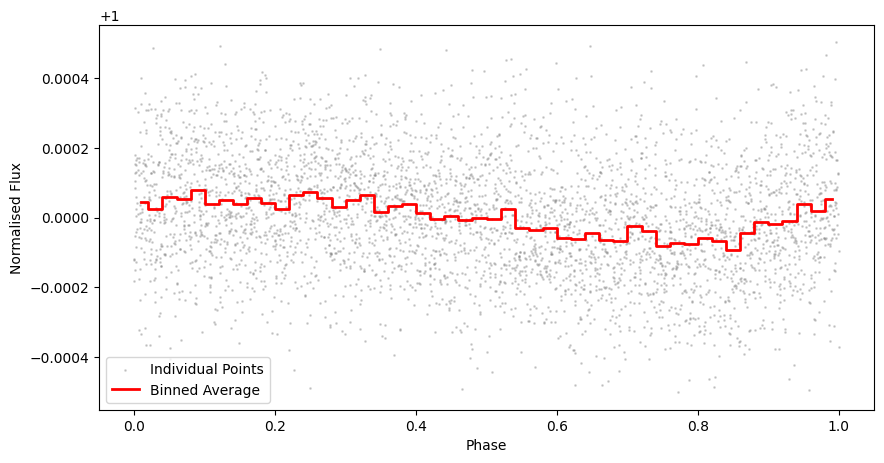

In [ ]:
# 1. Apply Sigma Clipping to remove extreme outliers
filtered_flux = sigma_clip(flux_norm, sigma=3)
mask = ~filtered_flux.mask
clean_phases = phases[mask]
clean_flux = flux_norm[mask]

# 2. Create Bins (e.g., 50 bins across the phase 0 to 1)
nbins = 50
bins = np.linspace(0, 1, nbins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
binned_flux = []

for i in range(nbins):
    indices = (clean_phases >= bins[i]) & (clean_phases < bins[i+1])
    if np.any(indices):
        binned_flux.append(np.mean(clean_flux[indices]))
    else:
        binned_flux.append(np.nan)

# 3. Plotting
plt.figure(figsize=(10, 5))
plt.scatter(clean_phases, clean_flux, s=1, color='gray', alpha=0.3, label="Individual Points")
plt.step(bin_centers, binned_flux, where='mid', color='red', linewidth=2, label="Binned Average")
plt.xlabel("Phase")
plt.ylabel("Normalised Flux")
plt.legend()
plt.show()

In [ ]:
# Narrow search around the peak we found
fine_freq = np.linspace(best_frequency - 0.05, best_frequency + 0.05, 10000)
power_fine = LombScargle(time, flux_norm).power(fine_freq)

best_freq_final = fine_freq[np.argmax(power_fine)]
refined_period = 1 / best_freq_final

print(f"Original Period: {period:.6f}")
print(f"Refined Period: {refined_period:.6f}")

Original Period: 2.880178
Refined Period: 2.878478


In [ ]:
def extract_features(file_path):

    with fits.open(file_path) as hdul:
        data = hdul[1].data
        time = data["TIME"]
        flux = data["PDCSAP_FLUX"]

    mask = np.isfinite(time) & np.isfinite(flux)
    time = time[mask]
    flux = flux[mask]

    flux_norm = flux / np.median(flux)

    # Basic stats
    mean_flux = np.mean(flux_norm)
    std_flux = np.std(flux_norm)
    amplitude = np.max(flux_norm) - np.min(flux_norm)

    # Moving average RMSE
    smoothed = pd.Series(flux_norm).rolling(20).mean()
    valid = ~np.isnan(smoothed)
    ma_deviation = np.sqrt(mean_squared_error(flux_norm[valid], smoothed[valid]))

    # ARIMA
    split = int(len(flux_norm) * 0.9)
    train, test = flux_norm[:split], flux_norm[split:]

    try:
        model = ARIMA(train, order=(1,0,1),
                      enforce_stationarity=False,
                      enforce_invertibility=False)

        model_fit = model.fit()
        forecast = model_fit.forecast(steps=len(test))
        arima_rmse = np.sqrt(mean_squared_error(test, forecast))

    except Exception:
        arima_rmse = np.nan

    # Lomb-Scargle
    try:
        frequency, power = LombScargle(time, flux_norm).autopower(
            minimum_frequency=0.1,
            maximum_frequency=5
        )

        power_peak = np.max(power)
        best_freq = frequency[np.argmax(power)]
        period = 1 / best_freq

    except Exception:
        power_peak = np.nan
        period = np.nan

    return [
        mean_flux,
        std_flux,
        amplitude,
        period,
        power_peak,
        arima_rmse,
        ma_deviation
    ]


# LOOP THROUGH ALL FILES
folder = "/content/drive/MyDrive/Data Science Module - Final Project/25 Stars Data"
features = []
names = []

for file in os.listdir(folder):
    if file.endswith(".fits"):
        path = os.path.join(folder, file)

        feat = extract_features(path)

        features.append(feat)
        names.append(file)

# CREATE DATASET
columns = [
    "mean_flux",
    "std_flux",
    "amplitude",
    "period",
    "power",
    "arima_rmse",
    "ma_deviation"
]

df = pd.DataFrame(features, columns=columns)
df["star"] = names

print(df)


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

    mean_flux  std_flux  amplitude     period     power  arima_rmse  \
0    1.000005  0.000176   0.002131   2.880178  0.062935    0.000172   
1    0.999821  0.003751   0.087590  10.000000  0.154251    0.004576   
2    0.998693  0.008227   0.083370   4.240014  0.057117    0.007779   
3    1.000003  0.000079   0.000630   8.330327  0.076978    0.000079   
4    1.000000  0.000159   0.001311   0.767692  0.013621    0.000158   
5    1.000000  0.000077   0.001166   4.450085  0.057279    0.000079   
6    0.999999  0.000043   0.000949   7.891137  0.026369    0.000039   
7    1.000001  0.000322   0.002406   8.998056  0.022648    0.000309   
8    0.999991  0.000492   0.005905   8.821290  0.046172    0.000562   
9    1.000001  0.000143   0.000942   8.651327  0.238028    0.000125   
10   0.999982  0.000113   0.001038   7.138458  0.101083    0.000050   
11   0.999590  0.001504   0.007307   2.202164  0.150671    0.001539   
12   0.999721  0.004778   0.024437  10.000000  0.014582    0.002344   
13   1

In [ ]:
df_before = df.copy()

df = df.replace([np.inf, -np.inf], np.nan)

print("Rows before cleaning:", len(df_before))
print("Missing values by column:")
print(df.isna().sum())

df = df.dropna()

print("Rows after dropna:", len(df))
print(df)

Rows before cleaning: 25
Missing values by column:
mean_flux       0
std_flux        0
amplitude       0
period          0
power           0
arima_rmse      0
ma_deviation    0
star            0
dtype: int64
Rows after dropna: 25
    mean_flux  std_flux  amplitude     period     power  arima_rmse  \
0    1.000005  0.000176   0.002131   2.880178  0.062935    0.000172   
1    0.999821  0.003751   0.087590  10.000000  0.154251    0.004576   
2    0.998693  0.008227   0.083370   4.240014  0.057117    0.007779   
3    1.000003  0.000079   0.000630   8.330327  0.076978    0.000079   
4    1.000000  0.000159   0.001311   0.767692  0.013621    0.000158   
5    1.000000  0.000077   0.001166   4.450085  0.057279    0.000079   
6    0.999999  0.000043   0.000949   7.891137  0.026369    0.000039   
7    1.000001  0.000322   0.002406   8.998056  0.022648    0.000309   
8    0.999991  0.000492   0.005905   8.821290  0.046172    0.000562   
9    1.000001  0.000143   0.000942   8.651327  0.238028    0

In [ ]:
df.to_csv("star_features.csv", index=False)

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["star"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## K-MEANS

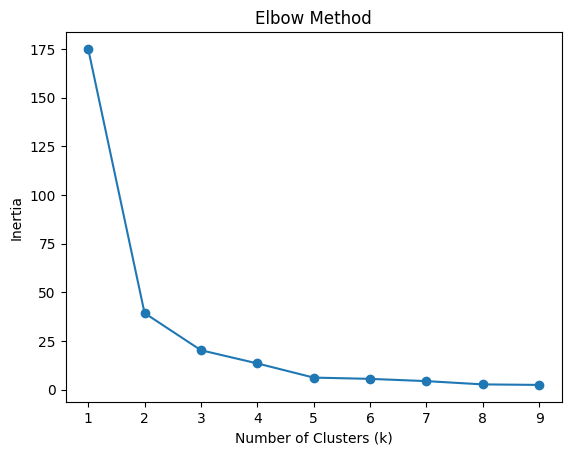

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

print(df["kmeans_cluster"].value_counts())

kmeans_cluster
2    15
0     9
1     1
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(n_clusters=3)
labels = kmeans.fit_predict(X_scaled)

score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.44562034487305063


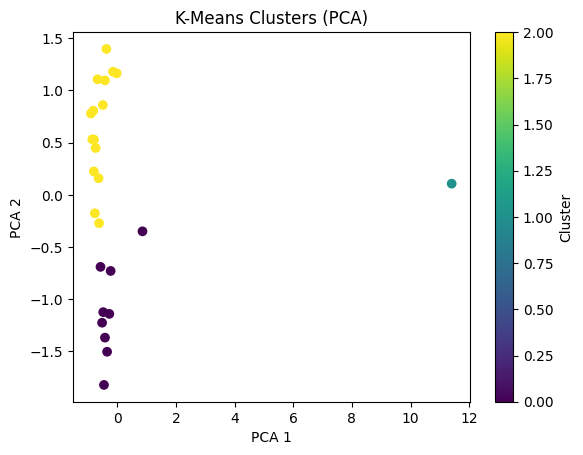

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["kmeans_cluster"])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters (PCA)")
plt.colorbar(label="Cluster")
plt.show()

## DBSCAN

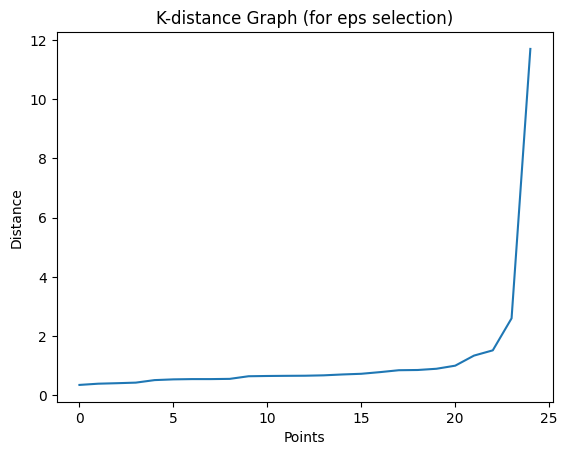

In [ ]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:,4])

plt.figure()
plt.plot(distances)
plt.title("K-distance Graph (for eps selection)")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=3)
df["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

In [ ]:
print(df["dbscan_cluster"].value_counts())

dbscan_cluster
 0    23
-1     2
Name: count, dtype: int64


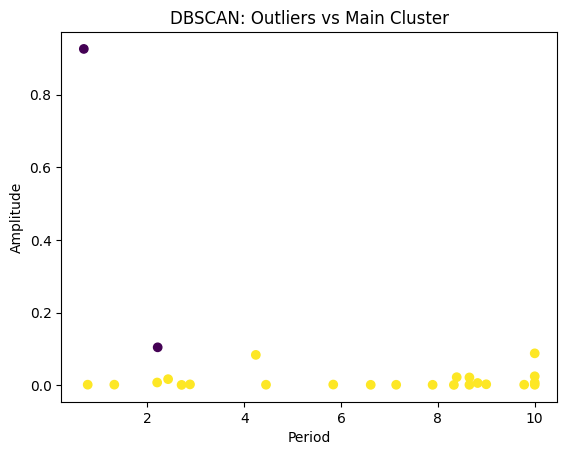

In [ ]:
plt.figure()
plt.scatter(df["period"], df["amplitude"], c=df["dbscan_cluster"])

plt.xlabel("Period")
plt.ylabel("Amplitude")
plt.title("DBSCAN: Outliers vs Main Cluster")
plt.show()

## Random Forest


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    df["kmeans_cluster"],
    test_size=0.3,
    random_state=42,
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(rf, param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.50      0.67         2

    accuracy                           0.86         7
   macro avg       0.92      0.75      0.79         7
weighted avg       0.88      0.86      0.84         7



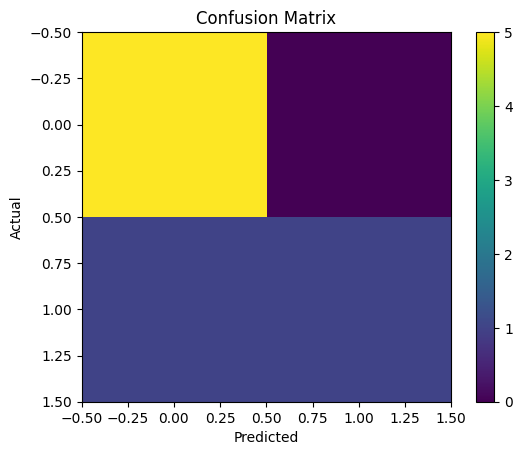

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

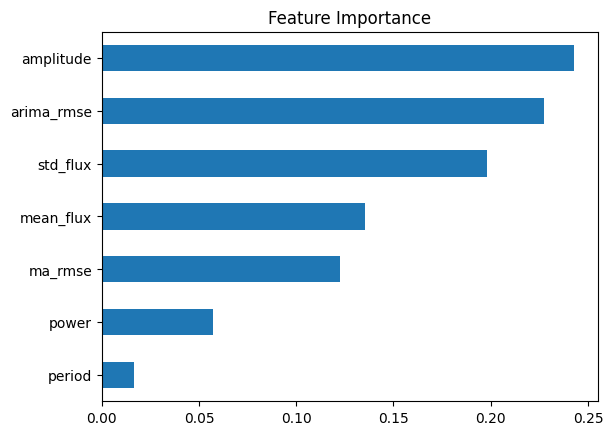

In [ ]:
import pandas as pd

importance = best_model.feature_importances_
feat_importance = pd.Series(importance, index=X.columns)

feat_importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [ ]:
df.head()

,mean_flux,std_flux,amplitude,period,power,arima_rmse,ma_rmse,star,kmeans_cluster,dbscan_cluster
0,1.000005,0.000176,0.002131,2.880178,0.062935,0.000172,0.000151,kplr008367947-2010078095331_llc.fits,0,0
1,0.999821,0.003751,0.087590,10.000000,0.154251,0.004576,0.001864,kplr000757450-2010078095331_llc.fits,1,-1
2,0.998693,0.008227,0.083370,4.240014,0.057117,0.007779,0.007946,kplr001026032-2010078095331_llc.fits,1,-1
3,1.000003,0.000079,0.000630,8.330327,0.076978,0.000079,0.000056,kplr011026764-2010078095331_llc.fits,0,0
4,1.000000,0.000159,0.001311,0.767692,0.013621,0.000158,0.000157,kplr010417986-2010078095331_llc.fits,0,0


In [ ]:
df.describe()

,mean_flux,std_flux,amplitude,period,power,arima_rmse,ma_rmse,kmeans_cluster,dbscan_cluster
count,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000,23.000000
mean,0.999944,0.001528,0.012731,6.525939,0.111742,0.001330,0.000888,0.217391,-0.304348
std,0.000341,0.002324,0.024179,3.176076,0.125538,0.002050,0.001818,0.421741,0.470472
min,0.998693,0.000043,0.000630,0.767692,0.000663,0.000039,0.000038,0.000000,-1.000000
25%,0.999992,0.000101,0.001015,3.560096,0.024509,0.000081,0.000057,0.000000,-1.000000
50%,1.000000,0.000180,0.001618,7.891137,0.062935,0.000172,0.000157,0.000000,0.000000
75%,1.000004,0.002100,0.011918,8.909673,0.152461,0.001819,0.000645,0.000000,0.000000
max,1.000795,0.008227,0.087590,10.000000,0.423357,0.007779,0.007946,1.000000,0.000000
